# E1b — per-layer localisation of the anchor-attention gap

Top-to-bottom reproducer for `docs/experiments/E1b-per-layer-localisation.md`
(detailed writeup) and `docs/insights/E1b-per-layer-localisation.md`
(distilled insight). Reads the four canonical `per_step_attention.jsonl`
files (already written by `scripts/extract_attention_mass.py`) and
regenerates:

1. Per-layer delta table + peak summary + budget decomposition,
2. Layer-trace figures for answer / step 0,
3. A supplementary budget-bar plot for the answer-step peak layer of each model.

Run top-to-bottom. All heavy lifting lives in `scripts/analyze_attention_per_layer.py` —
this notebook just invokes it and displays the outputs.

In [1]:
from __future__ import annotations

import importlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'scripts').exists() else Path.cwd().parent
assert (PROJECT_ROOT / 'scripts' / 'analyze_attention_per_layer.py').exists(), PROJECT_ROOT

import sys
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
import analyze_attention_per_layer as apl
importlib.reload(apl)

OUT_DIR = PROJECT_ROOT / 'outputs' / 'attention_analysis' / '_per_layer'
print('PROJECT_ROOT:', PROJECT_ROOT)
print('OUT_DIR:     ', OUT_DIR)
print('canonical runs:')
for m, r in apl.CANONICAL_RUNS.items():
    print(f'  {m:30s} -> {r}')

PROJECT_ROOT: /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing
OUT_DIR:      /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis/_per_layer
canonical runs:
  gemma4-e4b                     -> 20260424-115147
  qwen2.5-vl-7b-instruct         -> 20260424-120026
  llava-1.5-7b                   -> 20260424-121139
  internvl3-8b                   -> 20260424-121334


## 1. Regenerate the per-layer tables

Re-runs `scripts/analyze_attention_per_layer.py`. The script writes the CSV and PNG
outputs under `outputs/attention_analysis/_per_layer/`.

In [2]:
import subprocess
result = subprocess.run(
    ['uv', 'run', 'python', 'scripts/analyze_attention_per_layer.py'],
    cwd=PROJECT_ROOT, capture_output=True, text=True, check=True,
)
print(result.stdout.strip().splitlines()[-25:] if result.stdout else '(no stdout)')

['  [answer] n_triplets=135  n_layers=28  peak_layer=14  peak_delta=+0.01931', '  [step0] n_triplets=200  n_layers=28  peak_layer=3  peak_delta=+0.00760', '[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis/_per_layer/per_layer_deltas.csv', '[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis/_per_layer/peak_layer_summary.csv', '[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis/_per_layer/peak_budget_decomposition.csv', '[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis/_per_layer/fig_delta_by_layer_answer.png', '[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis/_per_layer/fig_delta_by_layer_step0.png', '', '=== Peak-layer summary (overall, answer step) ===', '                 model   step   n  n_layers  peak_layer  peak_layer_frac  peak_delta  peak_ci_low  peak_ci_high', '            gemma4-e4b answer 200        42           

## 2. Peak-layer summary (answer step, overall stratum)

In [3]:
peak = pd.read_csv(OUT_DIR / 'peak_layer_summary.csv')
answer_overall = peak.loc[(peak['step'] == 'answer') & (peak['stratum'] == 'all')].copy()
answer_overall['peak_layer_frac'] = answer_overall['peak_layer_frac'].round(3)
answer_overall[['peak_delta', 'peak_ci_low', 'peak_ci_high']] = (
    answer_overall[['peak_delta', 'peak_ci_low', 'peak_ci_high']].round(5)
)
answer_overall[['model', 'n', 'n_layers', 'peak_layer', 'peak_layer_frac',
                'peak_delta', 'peak_ci_low', 'peak_ci_high']]

,model,n,n_layers,peak_layer,peak_layer_frac,peak_delta,peak_ci_low,peak_ci_high
0,gemma4-e4b,200,42,5,0.122,0.05007,0.04772,0.05229
6,qwen2.5-vl-7b-instruct,200,28,22,0.815,0.01527,0.00842,0.02307
12,llava-1.5-7b,200,32,16,0.516,0.01883,0.01441,0.02310
18,internvl3-8b,135,28,14,0.519,0.01931,0.01348,0.02535


## 3. Peak-layer budget decomposition (answer step, number − neutral)

At the peak layer of each model, where does the positive `delta_anchor` come from?
Two patterns emerge: Gemma/LLaVA-1.5/InternVL3 pull from text; Qwen pulls from the
target image.

In [4]:
budget = pd.read_csv(OUT_DIR / 'peak_budget_decomposition.csv')
budget_r = budget.copy()
for c in ('d_image_anchor', 'd_image_target', 'd_text', 'd_generated', 'sum_check'):
    budget_r[c] = budget_r[c].round(5)
budget_r

,model,peak_layer,d_image_anchor,d_image_target,d_text,d_generated,sum_check
0,gemma4-e4b,5,0.05007,-0.00961,-0.03804,-0.00242,0.0
1,qwen2.5-vl-7b-instruct,22,0.01527,-0.00972,-0.00509,-0.00046,0.0
2,llava-1.5-7b,16,0.01883,0.00702,-0.02940,0.00355,0.0
3,internvl3-8b,14,0.01931,-0.00384,-0.01427,-0.00120,0.0


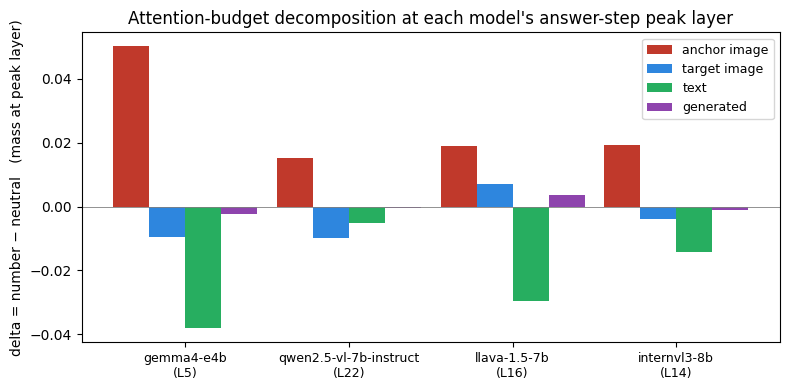

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
order = budget['model'].tolist()
x = np.arange(len(order))
w = 0.22
ax.bar(x - 1.5*w, budget['d_image_anchor'], width=w, color='#c0392b', label='anchor image')
ax.bar(x - 0.5*w, budget['d_image_target'], width=w, color='#2e86de', label='target image')
ax.bar(x + 0.5*w, budget['d_text'], width=w, color='#27ae60', label='text')
ax.bar(x + 1.5*w, budget['d_generated'], width=w, color='#8e44ad', label='generated')
ax.axhline(0, color='grey', lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n(L{int(budget['peak_layer'].iloc[i])})" for i, m in enumerate(order)],
                   fontsize=9)
ax.set_ylabel('delta = number − neutral   (mass at peak layer)')
ax.set_title('Attention-budget decomposition at each model\'s answer-step peak layer')
ax.legend(fontsize=9, loc='best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_peak_budget_decomposition.png', dpi=150)
plt.show()

## 4. Per-layer delta trace — answer step

Three lines per model: overall (black), top-decile susceptible (red), bottom-decile
resistant (blue). Gemma shows a narrow spike at layer 5; Qwen a late-stack peak at
layer 22; LLaVA-1.5 and InternVL3 peak mid-stack.

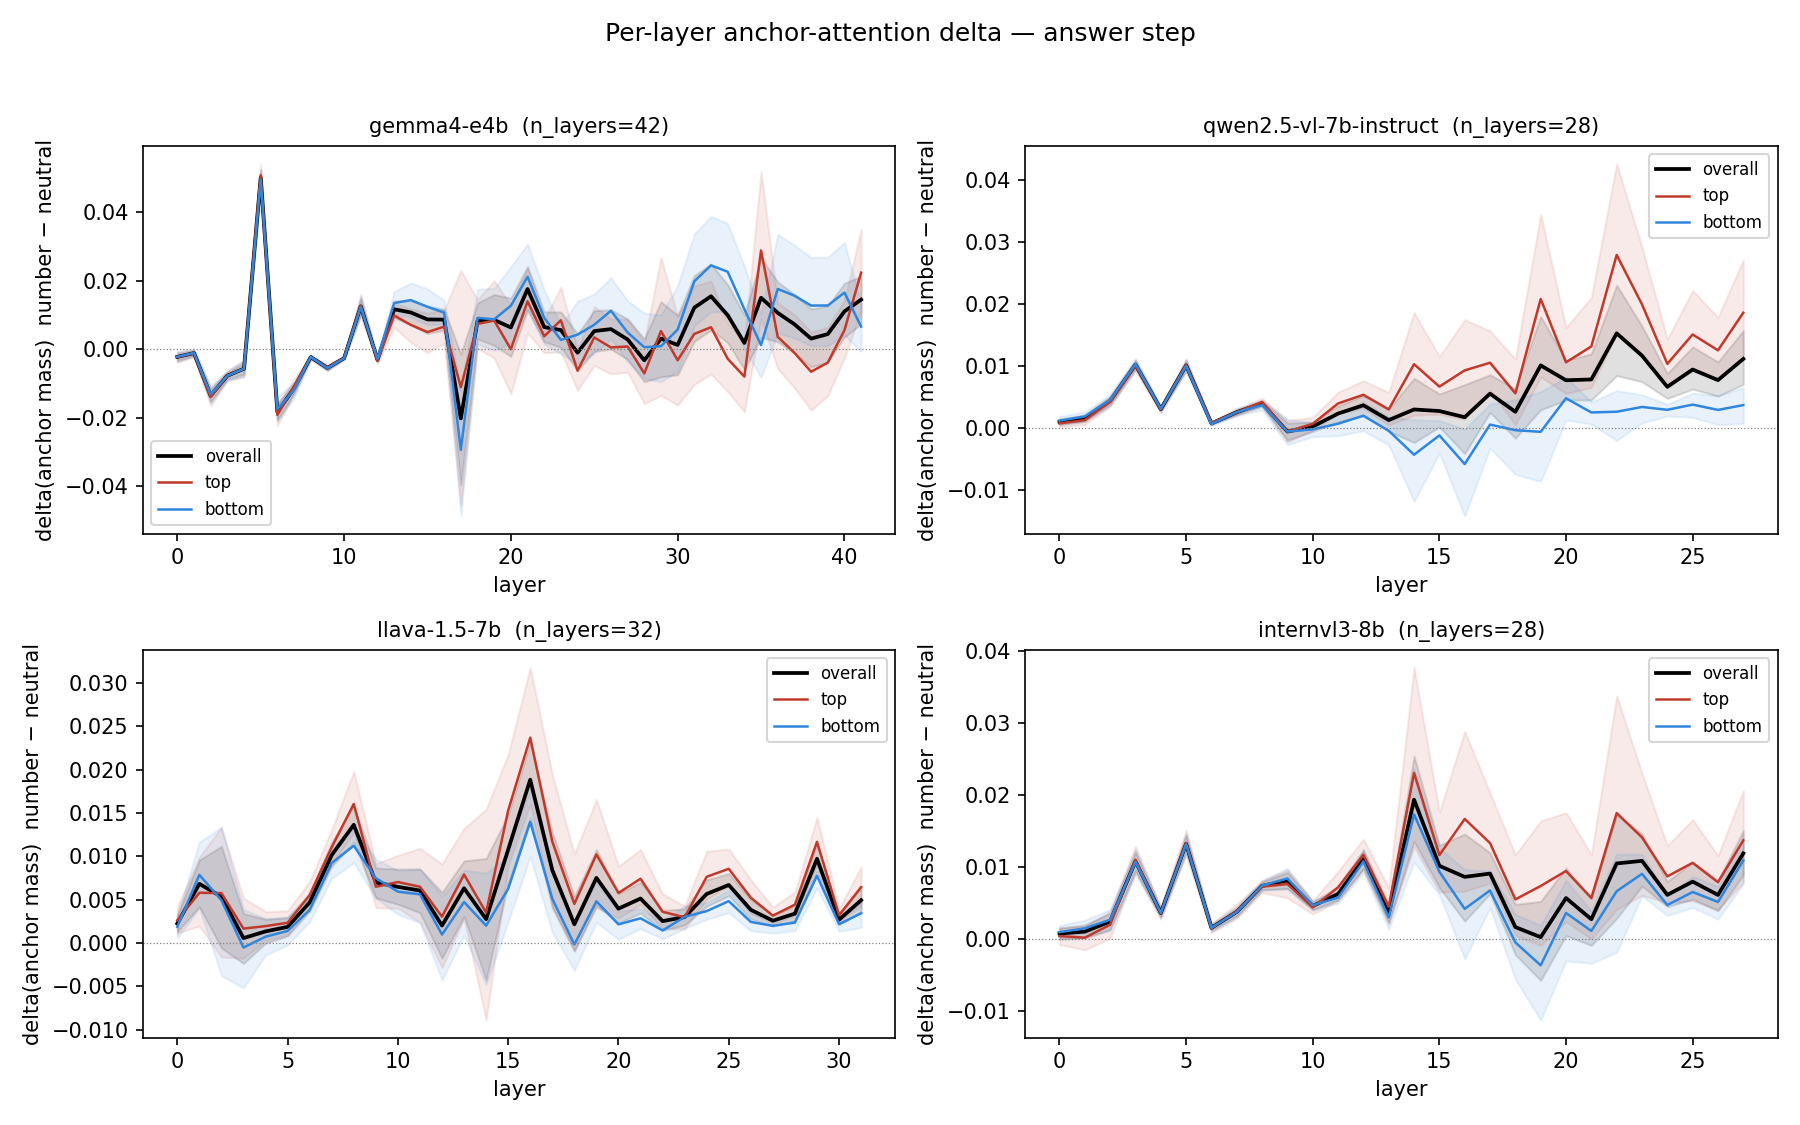

In [6]:
from IPython.display import Image
Image(filename=str(OUT_DIR / 'fig_delta_by_layer_answer.png'))

## 5. Per-layer delta trace — step 0

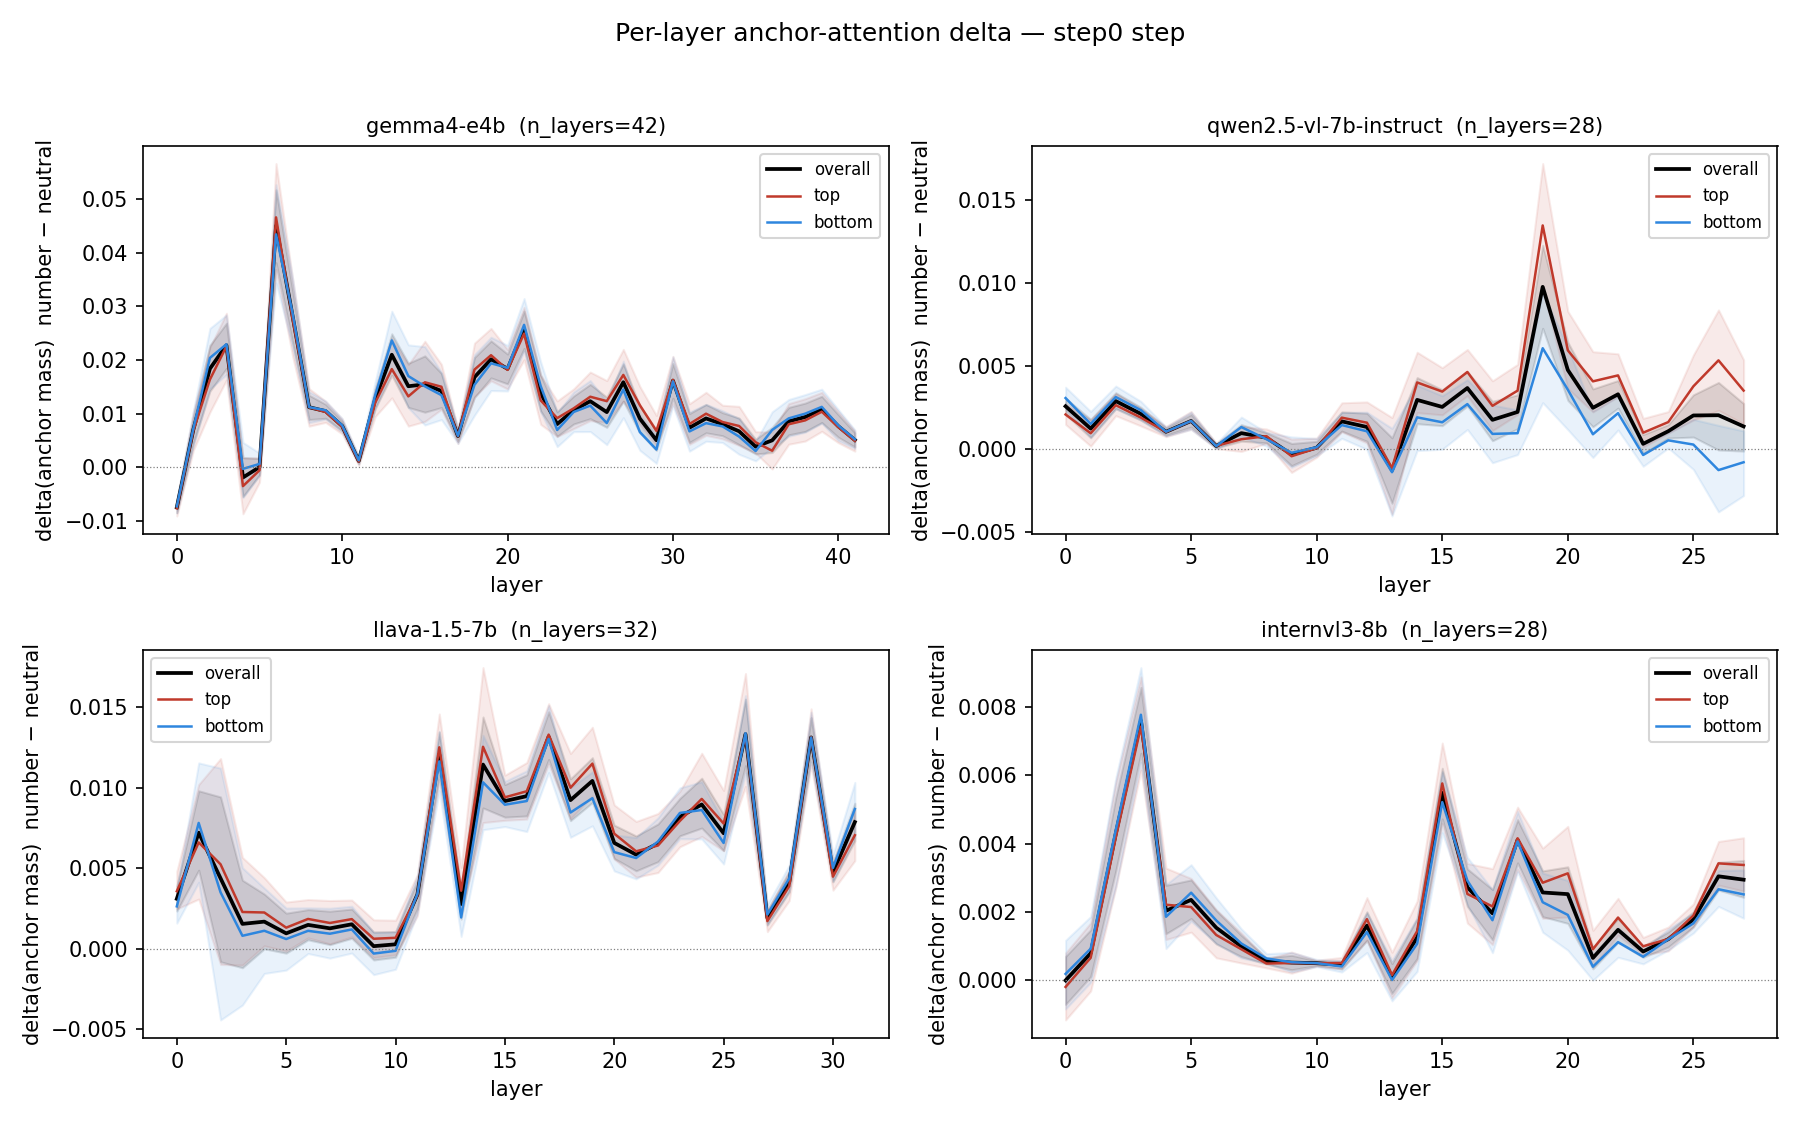

In [7]:
Image(filename=str(OUT_DIR / 'fig_delta_by_layer_step0.png'))

## 6. Gemma layer-5 deep-dive — knife-edge spike + mechanical trade-off layers

Per-layer budget for Gemma alone. Confirms: layer 5 is the only layer where anchor
genuinely pulls from text; the surrounding negative-delta layers are anchor/target
mass swaps (text unchanged).

In [8]:
model = 'gemma4-e4b'
jsonl = PROJECT_ROOT / 'outputs' / 'attention_analysis' / model / apl.CANONICAL_RUNS[model] / 'per_step_attention.jsonl'
records = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]
n_layers = records[0]['n_layers']

susc = pd.read_csv(PROJECT_ROOT / 'docs' / 'insights' / '_data' / 'susceptibility_strata.csv')
susceptibility = dict(zip(susc['question_id'].astype(int), susc['susceptibility_stratum']))

budget_g = apl._budget_decomposition(records, susceptibility, n_layers)
df_g = pd.DataFrame({
    'layer': np.arange(n_layers),
    'd_anchor': budget_g['image_anchor'],
    'd_target': budget_g['image_target'],
    'd_text':   budget_g['text'],
    'd_gen':    budget_g['generated'],
})
df_g.loc[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 17, 20, 30, 41]].round(5)

,layer,d_anchor,d_target,d_text,d_gen
0,0,-0.00221,0.00214,0.00007,0.00000
1,1,-0.00110,0.00318,-0.00208,0.00000
2,2,-0.01350,0.01362,-0.00012,0.00000
3,3,-0.00769,0.00771,-0.00002,0.00000
4,4,-0.00563,0.00941,-0.00378,0.00000
5,5,0.05007,-0.00961,-0.03804,-0.00242
6,6,-0.01828,0.01850,-0.00022,0.00000
7,7,-0.01136,0.01180,-0.00044,0.00000
8,8,-0.00227,0.00247,-0.00020,0.00000
9,9,-0.00541,0.00502,0.00039,0.00000


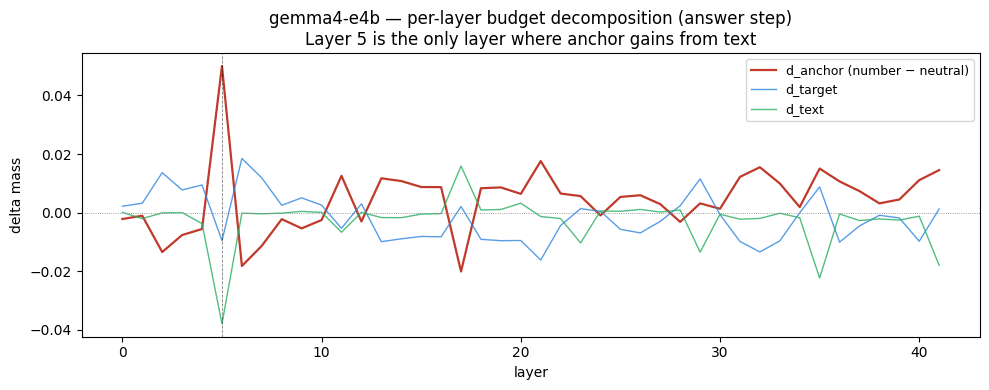

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_g['layer'], df_g['d_anchor'], color='#c0392b', lw=1.6, label='d_anchor (number − neutral)')
ax.plot(df_g['layer'], df_g['d_target'], color='#2e86de', lw=1.0, label='d_target', alpha=0.8)
ax.plot(df_g['layer'], df_g['d_text'],   color='#27ae60', lw=1.0, label='d_text', alpha=0.8)
ax.axhline(0, color='grey', lw=0.6, ls=':')
ax.axvline(5, color='black', lw=0.6, ls='--', alpha=0.5)
ax.set_xlabel('layer')
ax.set_ylabel('delta mass')
ax.set_title(f'{model} — per-layer budget decomposition (answer step)\nLayer 5 is the only layer where anchor gains from text')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_gemma_per_layer_budget.png', dpi=150)
plt.show()

## 7. Outputs

Files written / regenerated (all under `outputs/attention_analysis/_per_layer/`):

- `per_layer_deltas.csv`
- `peak_layer_summary.csv`
- `peak_budget_decomposition.csv`
- `fig_delta_by_layer_answer.png`
- `fig_delta_by_layer_step0.png`
- `fig_peak_budget_decomposition.png` (new, this notebook)
- `fig_gemma_per_layer_budget.png`   (new, this notebook)

Writeups: `docs/experiments/E1b-per-layer-localisation.md` (detailed), `docs/insights/E1b-per-layer-localisation.md` (distilled insight).